# benchmark_temps_execution

In [1]:
# notebooks/benchmark_temps_execution.ipynb
# ─────────────────────────────────────────────────────────────
# CELLULE 1 — Setup
# ─────────────────────────────────────────────────────────────

import sys
from pathlib import Path
import warnings
import time
warnings.filterwarnings("ignore")

RACINE = Path("..").resolve()
if str(RACINE) not in sys.path:
    sys.path.insert(0, str(RACINE))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from elasticsearch import Elasticsearch
import psycopg2
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from dotenv import load_dotenv
import os

load_dotenv(RACINE / ".env")
print("Imports OK")

Imports OK


In [2]:
# ─────────────────────────────────────────────────────────────
# CELLULE 2 — Connexions
# ─────────────────────────────────────────────────────────────

es = Elasticsearch(
    f"http://{os.getenv('ELASTIC_HOST', 'localhost')}:"
    f"{os.getenv('ELASTIC_PORT', 9200)}"
)
assert es.ping(), "Elasticsearch inaccessible"

conn = psycopg2.connect(
    host     = os.getenv("POSTGRES_HOST", "localhost"),
    port     = int(os.getenv("POSTGRES_PORT", 5432)),
    dbname   = os.getenv("POSTGRES_DB", "job_market"),
    user     = os.getenv("POSTGRES_USER"),
    password = os.getenv("POSTGRES_PASSWORD"),
)
print("Connexions OK")

Connexions OK


In [3]:
# ─────────────────────────────────────────────────────────────
# CELLULE 3 — Charger les données et entraîner les modèles
# ─────────────────────────────────────────────────────────────

# Charger les offres avec leurs labels
df = pd.read_sql("""
    SELECT
        o.id,
        o.titre,
        o.description,
        STRING_AGG(DISTINCT c.competence, ' ') AS competences,
        ml.ml_keyword
    FROM offres o
    JOIN ml_labels ml ON ml.offre_id = o.id
    LEFT JOIN competences c ON c.offre_id = o.id
    GROUP BY o.id, o.titre, o.description, ml.ml_keyword
""", conn)

df["texte"] = (
    df["titre"].fillna("")       + " " +
    df["titre"].fillna("")       + " " +
    df["description"].fillna("") + " " +
    df["competences"].fillna("")
)

keywords = df["ml_keyword"].unique().tolist()
print(f"{len(df)} offres chargées — {len(keywords)} keywords")

# Entraîner LR et SVM sur l'ensemble du dataset
# Variable cible = ml_keyword (multi-classes)
X = df["texte"].values
y = df["ml_keyword"].values

tfidf = TfidfVectorizer(
    max_features = 10000,
    ngram_range  = (1, 2),
    sublinear_tf = True,
)
X_tfidf = tfidf.fit_transform(X)

modeles = {
    "LR":  LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM": LinearSVC(max_iter=2000, class_weight="balanced"),
}

for nom, clf in modeles.items():
    clf.fit(X_tfidf, y)
    print(f"{nom} entraîné")

15048 offres chargées — 47 keywords
LR entraîné
SVM entraîné


In [4]:
# ─────────────────────────────────────────────────────────────
# CELLULE 4 — Mesure du temps d'exécution
# ─────────────────────────────────────────────────────────────

def mesurer_temps_es(keyword: str) -> float:
    """Mesure le temps d'une requête Elasticsearch en ms."""
    body = {
        "query": {
            "multi_match": {
                "query":  keyword,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": 100,
    }
    debut = time.perf_counter()
    es.search(index="offres", body=body)
    return (time.perf_counter() - debut) * 1000


def mesurer_temps_ml(keyword: str, modele, tfidf) -> float:
    """Mesure le temps de prédiction d'un modèle ML en ms."""
    x = tfidf.transform([keyword])
    debut = time.perf_counter()
    modele.predict(x)
    return (time.perf_counter() - debut) * 1000


# Mesure pour chaque keyword
resultats = []

for keyword in keywords:
    ligne = {"keyword": keyword}

    # Elasticsearch
    ligne["ES (ms)"] = round(mesurer_temps_es(keyword), 3)

    # LR et SVM
    for nom, clf in modeles.items():
        ligne[f"{nom} (ms)"] = round(
            mesurer_temps_ml(keyword, clf, tfidf), 3
        )

    resultats.append(ligne)
    print(
        f"  '{keyword}' — "
        f"ES={ligne['ES (ms)']}ms  "
        f"LR={ligne['LR (ms)']}ms  "
        f"SVM={ligne['SVM (ms)']}ms"
    )

df_temps = pd.DataFrame(resultats).set_index("keyword")

  'data scientist' — ES=18.657ms  LR=1.938ms  SVM=0.197ms
  'data manager' — ES=14.223ms  LR=0.683ms  SVM=0.105ms
  'data steward' — ES=14.902ms  LR=0.739ms  SVM=0.13ms
  'ingénieur données' — ES=16.667ms  LR=0.753ms  SVM=0.098ms
  'business intelligence' — ES=10.283ms  LR=0.966ms  SVM=0.141ms
  'data analyst' — ES=10.231ms  LR=1.013ms  SVM=0.276ms
  'architecte données' — ES=10.865ms  LR=0.661ms  SVM=0.099ms
  'architecte data' — ES=10.092ms  LR=0.751ms  SVM=0.105ms
  'architecte solution' — ES=11.611ms  LR=0.693ms  SVM=0.123ms
  'scrum master' — ES=9.743ms  LR=0.702ms  SVM=0.097ms
  'ingénieur machine learning' — ES=10.895ms  LR=0.718ms  SVM=0.102ms
  'UX designer' — ES=10.474ms  LR=0.817ms  SVM=0.105ms
  'analyste données' — ES=9.704ms  LR=0.812ms  SVM=0.132ms
  'développeur backend' — ES=10.414ms  LR=1.428ms  SVM=0.098ms
  'ingénieur data' — ES=10.615ms  LR=0.733ms  SVM=0.123ms
  'pipeline données' — ES=8.841ms  LR=0.791ms  SVM=0.099ms
  'data quality' — ES=11.412ms  LR=0.698ms  SV

In [5]:
# ─────────────────────────────────────────────────────────────
# CELLULE 5 — Tableau récapitulatif
# ─────────────────────────────────────────────────────────────

# Ajouter une ligne de moyenne
df_temps.loc["MOYENNE"] = df_temps.mean().round(3)

print("\n=== TEMPS D'EXÉCUTION PAR REQUÊTE (ms) ===\n")
print(df_temps.to_string())


=== TEMPS D'EXÉCUTION PAR REQUÊTE (ms) ===

                            ES (ms)  LR (ms)  SVM (ms)
keyword                                               
data scientist               18.657    1.938     0.197
data manager                 14.223    0.683     0.105
data steward                 14.902    0.739     0.130
ingénieur données            16.667    0.753     0.098
business intelligence        10.283    0.966     0.141
data analyst                 10.231    1.013     0.276
architecte données           10.865    0.661     0.099
architecte data              10.092    0.751     0.105
architecte solution          11.611    0.693     0.123
scrum master                  9.743    0.702     0.097
ingénieur machine learning   10.895    0.718     0.102
UX designer                  10.474    0.817     0.105
analyste données              9.704    0.812     0.132
développeur backend          10.414    1.428     0.098
ingénieur data               10.615    0.733     0.123
pipeline données    

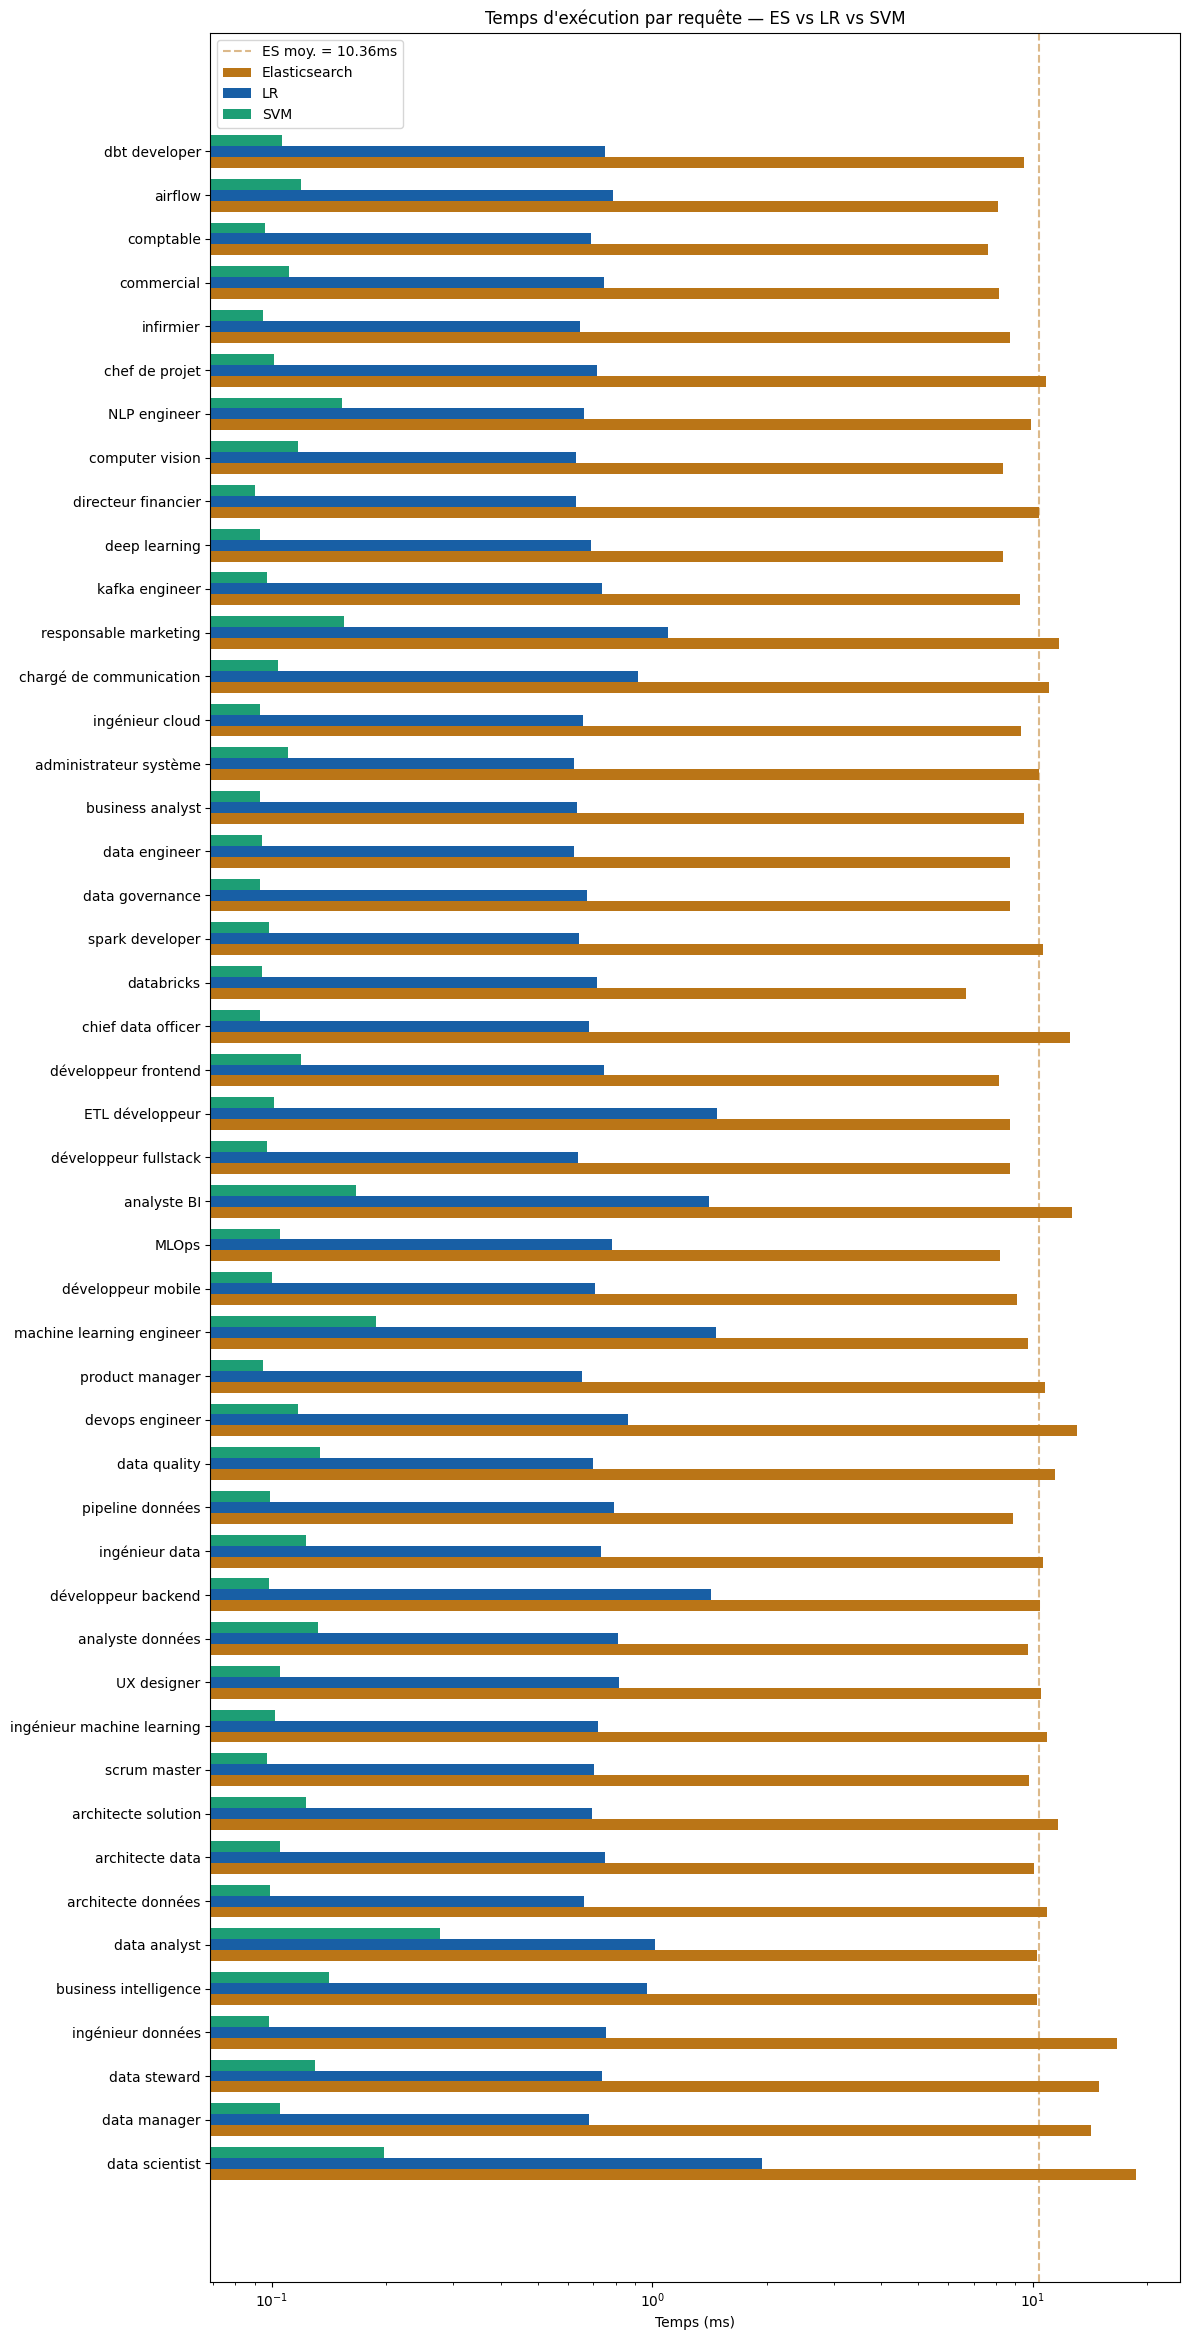

Connexions fermées.


In [6]:
# ─────────────────────────────────────────────────────────────
# CELLULE 6 — Visualisation
# ─────────────────────────────────────────────────────────────

df_plot = df_temps.drop("MOYENNE")

fig, ax = plt.subplots(figsize=(12, max(5, len(df_plot) * 0.5)))

x = np.arange(len(df_plot))
w = 0.25

ax.barh(x - w,   df_plot["ES (ms)"],  w, label="Elasticsearch", color="#BA7517")
ax.barh(x,       df_plot["LR (ms)"],  w, label="LR",            color="#185FA5")
ax.barh(x + w,   df_plot["SVM (ms)"], w, label="SVM",           color="#1D9E75")

ax.set_yticks(x)
ax.set_yticklabels(df_plot.index)
ax.set_xlabel("Temps (ms)")
ax.set_title("Temps d'exécution par requête — ES vs LR vs SVM")
ax.axvline(
    x         = df_plot["ES (ms)"].mean(),
    color     = "#BA7517",
    linestyle = "--",
    alpha     = 0.5,
    label     = f"ES moy. = {df_plot['ES (ms)'].mean():.2f}ms"
)
ax.legend()
ax.set_xscale("log")   # échelle log — les ordres de grandeur sont très différents

plt.tight_layout()
plt.savefig("benchmark_temps.png", dpi=150, bbox_inches="tight")
plt.show()

conn.close()
print("Connexions fermées.")